link: https://www.kaggle.com/code/hamidrana/dogvscats-using-alexnet-architecture

In [ ]:
import os

base_path = "/kaggle/input/datasets/salader/dogsvscats"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

print(train_path)
print(test_path)

/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/test


In [19]:
import tensorflow as tf 
import keras 
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Rescaling, RandomFlip, RandomRotation,
    RandomZoom, RandomTranslation
)

from sklearn.metrics import accuracy_score
import cv2
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np

import random

In [20]:
# generators (devides data into batches)
# use full for large impout of data

In [21]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(227,227)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(227,227)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


# Training

## create CNN model

In [22]:
model = Sequential([
    keras.layers.Input(shape=(227, 227, 3)),
    
    # Normalize pixel values
    Rescaling(1./255),

    # Data augmentation (applied only during training)
    # RandomFlip("horizontal"),
    # RandomRotation(0.1),
    # RandomZoom(0.2),
    # RandomTranslation(0.2, 0.2),

    # Convolution Block 1
    Conv2D(96, (11,11), activation='relu', padding='valid',strides=4,
           input_shape=(227,227,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3),strides=2),

    # Convolution Block 2
    Conv2D(256, (5,5), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3),strides=2),

    # Convolution Block 3
    Conv2D(384, (3,3), activation='relu',padding='same'),
    BatchNormalization(),
    # MaxPooling2D(pool_size=(3,3)),

    # Convolution Block 4
    Conv2D(384, (3,3), activation='relu',padding='same'),
    BatchNormalization(),
    # MaxPooling2D(pool_size=(3,3),strides=2),

    # Convolution Block 5
    Conv2D(256, (3,3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3),strides=2),


    Flatten(),

    Dense(4096, activation='relu'),
    # Dropout(0.2),

    Dense(4096, activation='relu'),
    # Dropout(0.2),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,290,945 (222.36 MB)

 Trainable params: 58,288,193 (222.35 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [24]:
callback = EarlyStopping(
    monitor='val_loss', # watches validation loss each epoch
    verbose=1,
    patience=3,             
    restore_best_weights=True  # rolls back to the best epoch's weights when it stops
)

In [25]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds,callbacks=callback)
# there are 625 batches

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.5897 - loss: 2.5743 - val_accuracy: 0.5046 - val_loss: 1.0545
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7164 - loss: 0.5652 - val_accuracy: 0.7190 - val_loss: 0.5455
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7897 - loss: 0.4576 - val_accuracy: 0.6994 - val_loss: 0.6336
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8412 - loss: 0.3714 - val_accuracy: 0.6582 - val_loss: 0.8765
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8685 - loss: 0.3118 - val_accuracy: 0.8456 - val_loss: 0.3632
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8888 - loss: 0.2666 - val_accuracy: 0.7114 - val_loss: 0.6529
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9068 - loss: 0.2286 - val_accuracy: 0.8452 - val_loss: 0.3572
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9208 - loss: 0.2035 - 

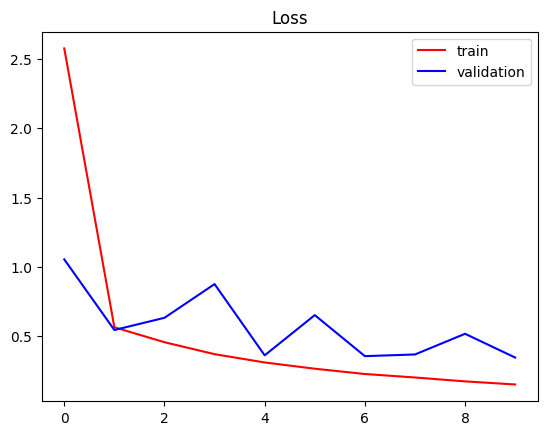

In [27]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

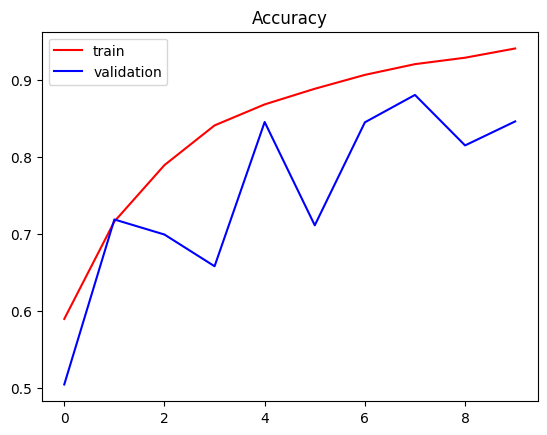

In [28]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [29]:
# ways to reduce overfitting 

# add more data
# data augmentation
# l1/l2 regularilization
# dropout
# Batch Normalization
# reduce model complexity

In [30]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/marquis03/cats-and-dogs'):
    print(dirname,'\n',filenames)
    break

/kaggle/input/datasets/marquis03/cats-and-dogs 
 ['val.csv', 'train.csv']


In [31]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv')
df.head()

,image:FILE,category
0,val/cat/Persian_13_jpg.rf.dd6ccb81649242fcc8a2...,0
1,val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9d...,0
2,val/cat/Siamese_142_jpg.rf.de98806682118bd0281...,0
3,val/cat/Birman_163_jpg.rf.de852821da3d65ebd262...,0
4,val/cat/Bengal_141_jpg.rf.e656908b712d2cb13742...,0


# Testing

In [32]:
import cv2

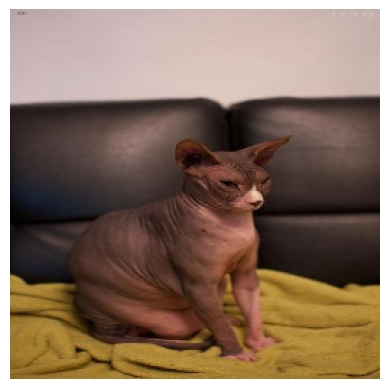

True: cat | Predicted: cat | Raw score: 0.0095


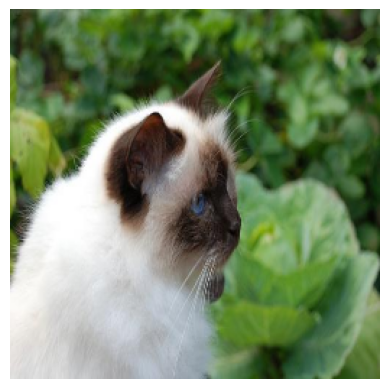

True: cat | Predicted: dog | Raw score: 0.9993


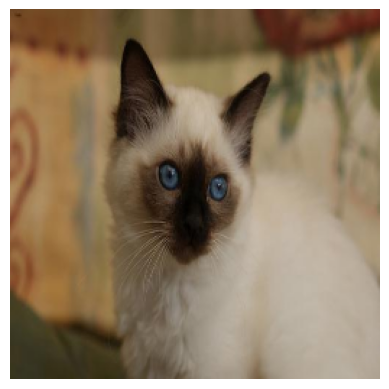

True: cat | Predicted: cat | Raw score: 0.0008


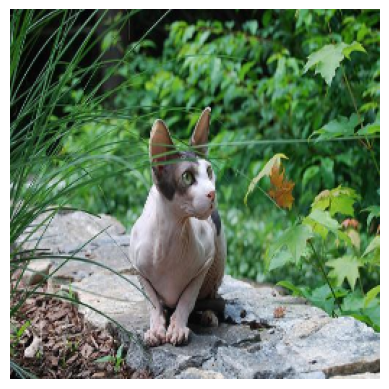

True: cat | Predicted: dog | Raw score: 0.8665


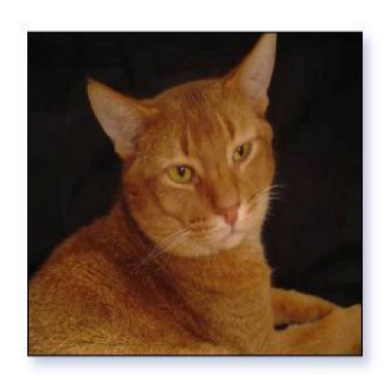

True: cat | Predicted: cat | Raw score: 0.0000


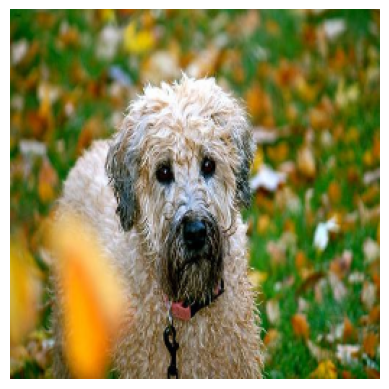

True: dog | Predicted: dog | Raw score: 0.9977


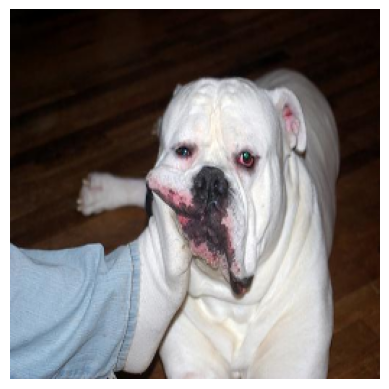

True: dog | Predicted: dog | Raw score: 1.0000


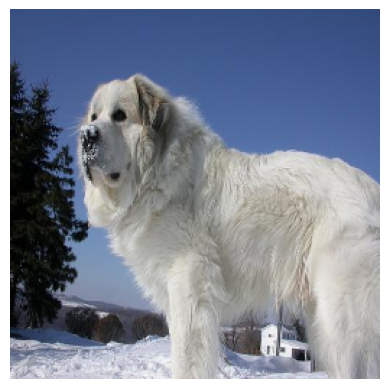

True: dog | Predicted: dog | Raw score: 0.9391


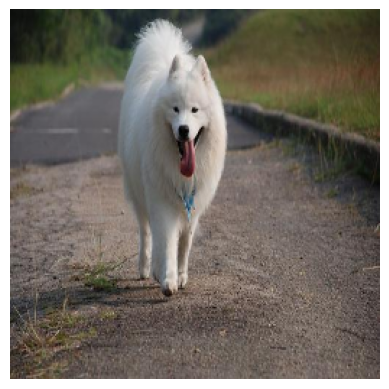

True: dog | Predicted: dog | Raw score: 0.9987


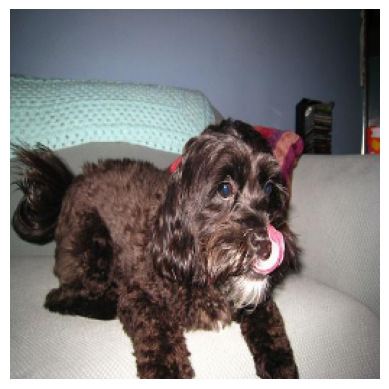

True: dog | Predicted: dog | Raw score: 0.9744


In [33]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

# Pick 5 cats (category == 0) and 5 dogs (category == 1) explicitly
cats_sample = df[df["category"] == 0].sample(5, random_state=None).reset_index(drop=True)
dogs_sample = df[df["category"] == 1].sample(5, random_state=None).reset_index(drop=True)
sample = pd.concat([cats_sample, dogs_sample]).reset_index(drop=True)

for _, row in sample.iterrows():
    image_path = os.path.join(path, row["image:FILE"])
    true_label = "dog" if row["category"] == 1 else "cat"

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # NOTE: no manual /255.0 here — the model already has a Rescaling(1./255) layer.
    # Feed it raw pixel values (0-255), just as float32.
    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    prediction = model.predict(img_input, verbose=0)
    y_pred = np.where(prediction > 0.5, 1, 0)   # 0.5 is the standard threshold for sigmoid
    pred_label = "dog" if y_pred[0][0] == 1 else "cat"

    print(f"True: {true_label} | Predicted: {pred_label} | Raw score: {prediction[0][0]:.4f}")

In [34]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"

y_true = []
y_pred = []

for _, row in df.iterrows():
    image_path = os.path.join(path, row["image:FILE"])

    # Read and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    img_input = img.astype("float32")
    img_input = np.expand_dims(img_input, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0][0]

    predicted_label = 1 if pred > 0.5 else 0

    # Save labels
    y_true.append(row["category"])
    y_pred.append(predicted_label)

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Accuracy: 0.7857
Validation Accuracy: 78.57%
